<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [2]:
# Your code here
data = pd.read_csv('./data/College.csv')
data.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [3]:
college = data.copy()
college = college.rename(columns = {'Unnamed: 0': 'Name'})
college.head()

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [4]:
# Your code here
college.shape

(777, 19)

In [5]:
college.dtypes

Name               str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

In [6]:
college.isnull().sum()

Name           0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [7]:
college['PhD'].unique()

<ArrowStringArray>
[ '70',  '29',  '53',  '92',  '76',   '?',  '90',  '89',  '79',  '40',  '82',
  '73',  '60',  '36',  '78',  '48',  '62',  '69',  '83',  '55',  '88',  '57',
  '93',  '85',  '65',  '66',  '81',  '59',  '58',  '68',  '98',  '71',  '74',
  '61',  '35',  '87',  '80',  '63',  '75',  '39',  '99', '100',  '95',  '77',
  '72',  '64',  '10',  '86',  '22',  '50',  '41',   '8',  '67',  '94',  '56',
  '46',  '54',  '84',  '97',  '51',  '42',  '49',  '52',  '43',  '37',  '45',
  '47',  '91',  '31',  '96',  '34',  '33',  '44',  '32',  '14', '103',  '26',
  '16']
Length: 78, dtype: str

In [8]:
# Your code here
college['PhD'] = pd.to_numeric(college['PhD'], errors='coerce')
college.isnull().sum()

Name            0
Private         0
Apps            0
Accept          0
Enroll          0
Top10perc       0
Top25perc       0
F.Undergrad     0
P.Undergrad     0
Outstate        0
Room.Board      0
Books           0
Personal        0
PhD            29
Terminal        0
S.F.Ratio       0
perc.alumni     0
Expend          0
Grad.Rate       0
dtype: int64

In [9]:
college['PhD'] = college['PhD'].fillna(college['PhD'].median())
college.isnull().sum()

Name           0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

In [10]:
college[college['PhD'] > 100]

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
582,Texas A&M University at Galveston,No,529,481,243,22,47,1206,134,4860,3122,600,650,103.0,88,17.4,16,6415,43


In [11]:
college[college['PhD'] < 0]

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate


In [12]:
college.loc[college['PhD'] > 100, 'PhD'] = college['PhD'].median()
college[college['PhD'] > 100]

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate


#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [13]:
college['Grad.Rate'].unique()

array([ 60,  56,  54,  59,  15,  55,  63,  73,  80,  52,  76,  74,  68,
        69, 100,  46,  34,  48,  70,  65,  88,  58,  71,  85,  79,  91,
        72,  84,  49,  82,  35,  51,  75,  53,  96,  67,  18,  33,  97,
        89,  93,  78,  83,  61,  81,  64,  62, 118,  24,  66,  47,  50,
        21,  87,  77,  43,  95,  37,  99,  45,  42,  98,  94,  38,  86,
        44,  22,  57,  29,  36,  39,  40,  26,  90,  92,  32,  27,  41,
        31,  10,  30])

In [14]:
college[college['Grad.Rate'] > 100]

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
95,Cazenovia College,Yes,3847,3433,527,9,35,1010,12,9384,4840,600,500,22.0,47,14.3,20,7697,118


In [15]:
college[college['Grad.Rate'] < 0]

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate


In [16]:
# Your code here
college.loc[college['Grad.Rate'] > 100, 'Grad.Rate'] = college['Grad.Rate'].median()
college[college['Grad.Rate'] > 100]

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate


## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox, yeojohnson

In [18]:
%%writefile myutils.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox, yeojohnson

def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    results = []
    
    for col in numeric_cols:
        # Skip columns containing 'id' or binary/encoded variables
        if 'id' in str(col).lower() or df[col].nunique() <= 2:
            continue
            
        series = df[col].dropna()
        if series.empty:
            continue
            
        skew = series.skew()
        abs_skew = abs(skew)
        min_val = series.min()
        
        # Determine Degree and Direction
        if abs_skew < 0.5:
            degree = "Approximately Normal"
            direction = "Symmetric"
            recommendation = "No transformation needed"
        else:
            if skew > 0:
                direction = "Right (Positive)"
            else:
                direction = "Left (Negative)"
            
            if 0.5 <= abs_skew <= 1.0:
                degree = "Moderately Skewed"
            else:
                degree = "Highly Skewed"
                
            # Recommendations
            if skew > 0 and abs_skew > 1.0:
                if min_val > 0:
                    recommendation = "Box-Cox or Yeo-Johnson"
                elif min_val == 0:
                    recommendation = "log(x+1) or Yeo-Johnson"
                else:
                    recommendation = "Yeo-Johnson"

            elif skew > 0 and 0.5 <= abs_skew <= 1.0:
                if min_val > 0:
                    recommendation = "log(x+1) or Yeo-Johnson"
                elif min_val == 0:
                    recommendation = "log(x+1) or Yeo-Johnson"
                else:
                    recommendation = "Yeo-Johnson"

            else:
                if min_val > 0:
                    recommendation = "Box-Cox or Yeo-Johnson"
                else:
                    recommendation = "Yeo-Johnson"

        results.append({
            'Feature': col,
            'Skewness': round(skew, 4),
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': recommendation
        })
        
    return pd.DataFrame(results)

Overwriting myutils.py


In [19]:
from myutils import skew_calc

In [20]:
def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
    cols_to_transform = skew_table[
        skew_table['Recommended Transformation'] != "No transformation needed"
    ]
    
    if cols_to_transform.empty:
        print("No columns require transformation!")
        return

    sns.set_theme(style="whitegrid")
    
    # Iterate through each row in cols_to_transform
    for idx, row in cols_to_transform.iterrows():
        col = row['Feature']
        original_skew = row['Skewness']
        rec = str(row['Recommended Transformation'])
        
        original_data = df[col].dropna()
        
        try:
            # 1. Box-Cox (Requires strictly positive values > 0)
            if "Box-Cox" in rec and (original_data > 0).all():
                transformed_data, _ = boxcox(original_data)
                applied_name = "Box-Cox"
                
            # 2. log1p (Requires non-negative values >= 0)
            elif "log(x+1)" in rec and (original_data >= 0).all():
                transformed_data = np.log1p(original_data)
                applied_name = "log1p"
                
            # 3. Fallback to Yeo-Johnson (Handles all real numbers including <= 0)
            else:
                transformed_data, _ = yeojohnson(original_data)
                applied_name = "Yeo-Johnson"
                
        except Exception as e:
            print(f"Could not transform column '{col}': {e}")
            continue
            
        new_skew = round(pd.Series(transformed_data).skew(), 4)
        
        # Plotting Before vs After (1 row, 2 columns per feature)
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        
        # Original Distribution
        sns.histplot(original_data, kde=True, ax=axes[0], alpha=1.0)
        axes[0].set_title(f"Original: {col}\n(Skewness: {original_skew})", fontsize=10)
        axes[0].set_xlabel("Value")
        axes[0].set_ylabel("Count")
        
        # Transformed Distribution
        sns.histplot(transformed_data, kde=True, ax=axes[1], alpha=1.0)
        axes[1].set_title(f"After {applied_name}\n(New Skewness: {new_skew})", fontsize=10)
        axes[1].set_xlabel("Transformed Value")
        axes[1].set_ylabel("Count")
        
        plt.tight_layout()
        plt.show()

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [21]:
# Your code here
skew = skew_calc(college)
skew

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.7237,Highly Skewed,Right (Positive),Box-Cox or Yeo-Johnson
1,Accept,3.4177,Highly Skewed,Right (Positive),Box-Cox or Yeo-Johnson
2,Enroll,2.6905,Highly Skewed,Right (Positive),Box-Cox or Yeo-Johnson
3,Top10perc,1.4132,Highly Skewed,Right (Positive),Box-Cox or Yeo-Johnson
4,Top25perc,0.2593,Approximately Normal,Symmetric,No transformation needed
5,F.Undergrad,2.6105,Highly Skewed,Right (Positive),Box-Cox or Yeo-Johnson
6,P.Undergrad,5.6924,Highly Skewed,Right (Positive),Box-Cox or Yeo-Johnson
7,Outstate,0.5093,Moderately Skewed,Right (Positive),log(x+1) or Yeo-Johnson
8,Room.Board,0.4774,Approximately Normal,Symmetric,No transformation needed
9,Books,3.4850,Highly Skewed,Right (Positive),Box-Cox or Yeo-Johnson


In [ ]:
# Your code here

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


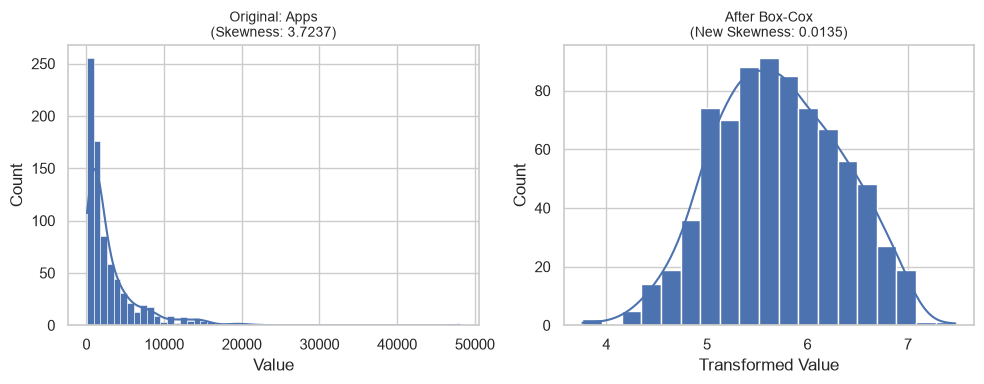

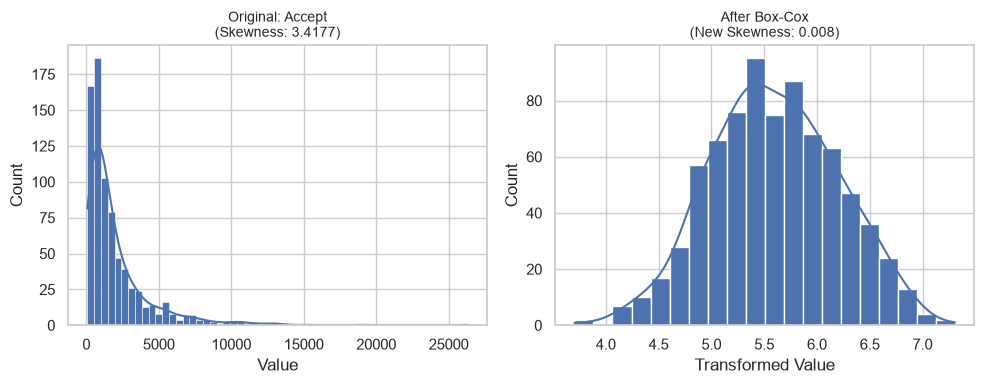

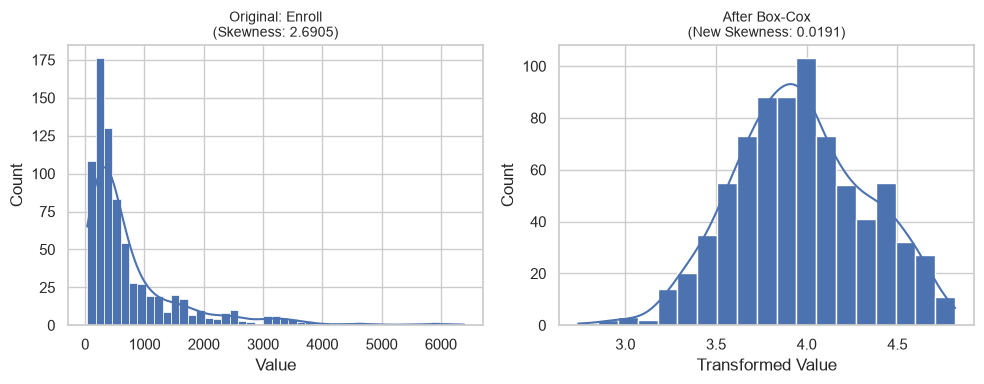

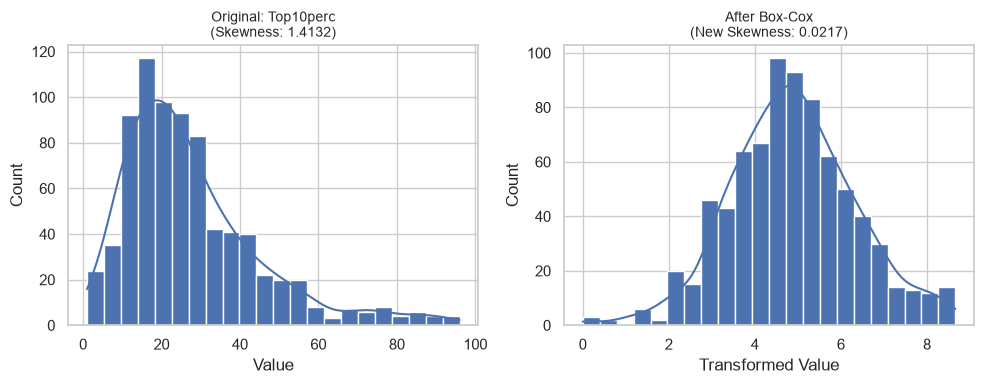

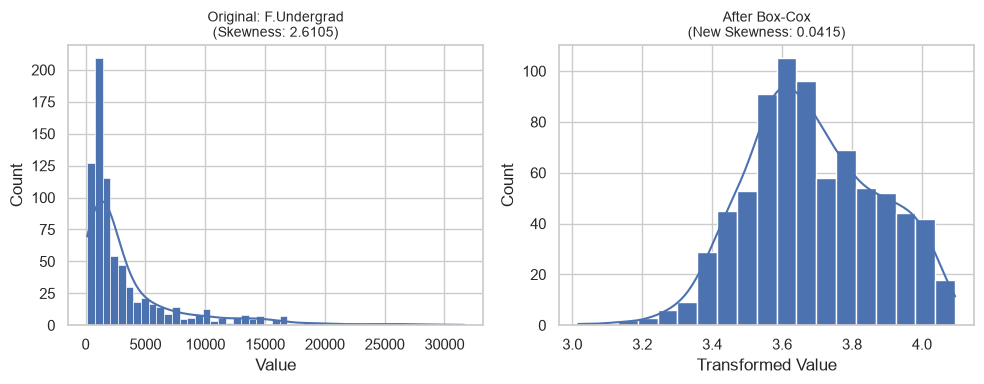

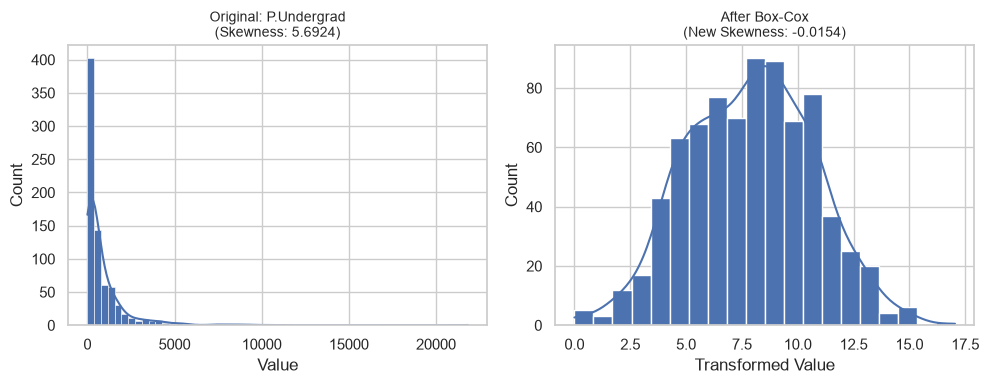

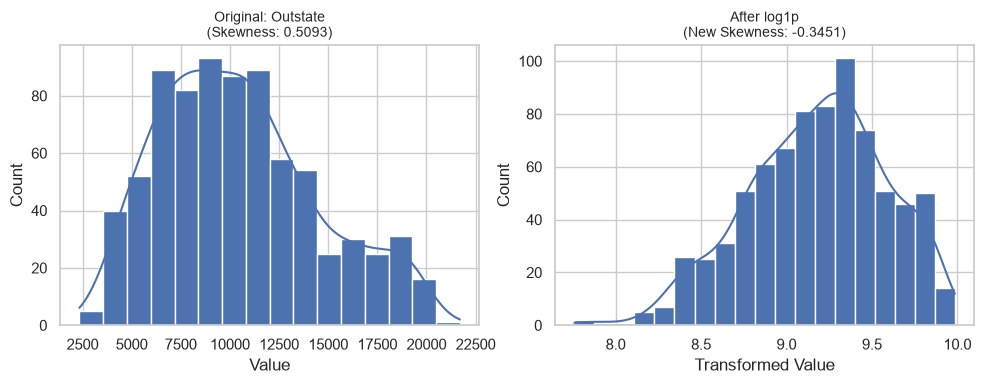

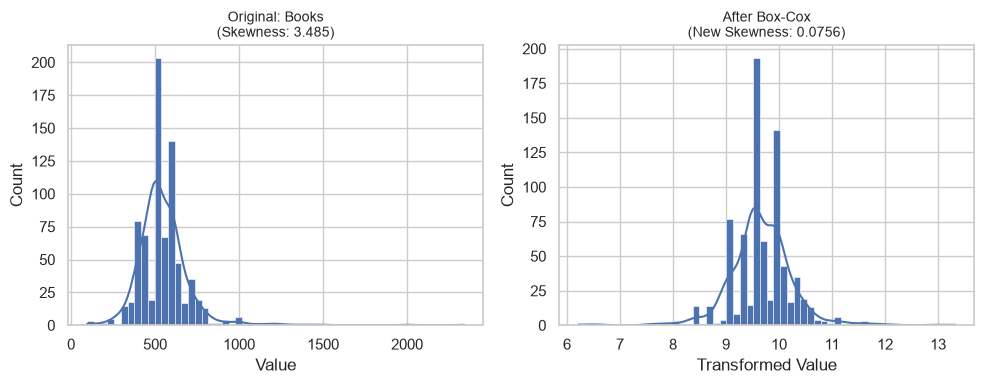

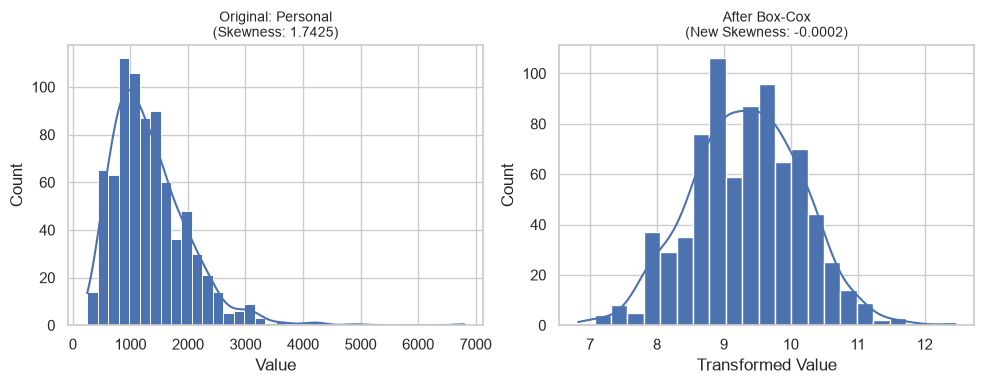

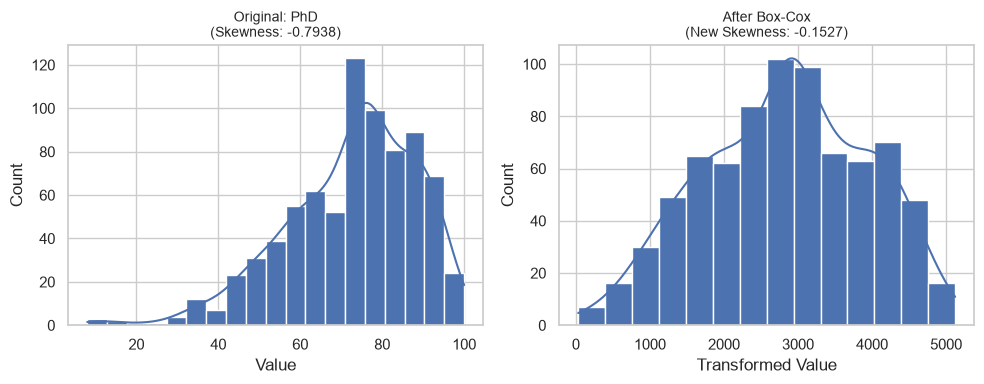

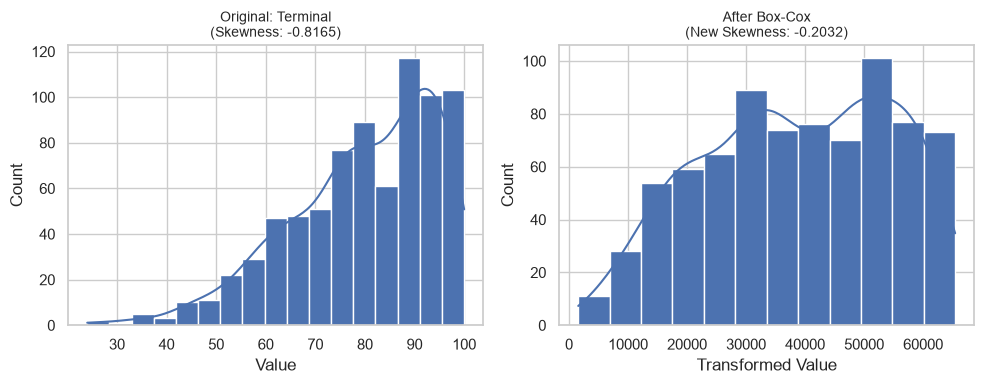

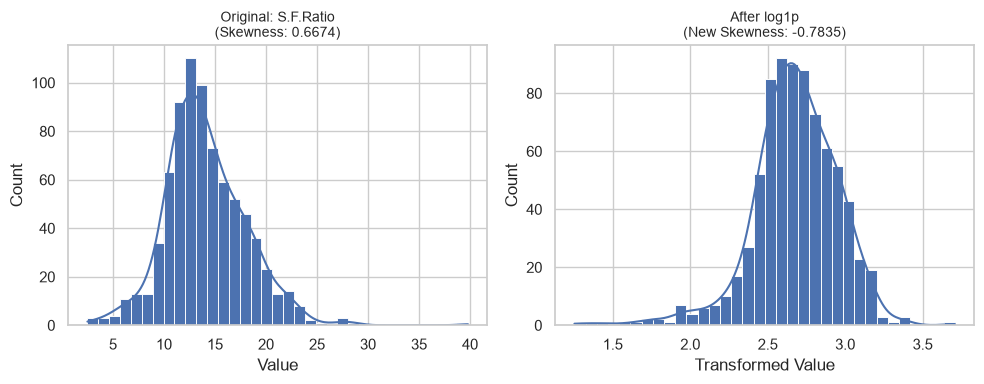

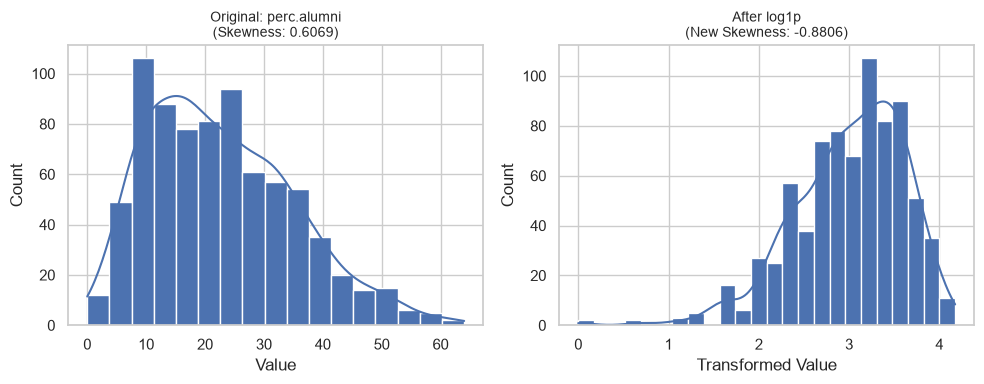

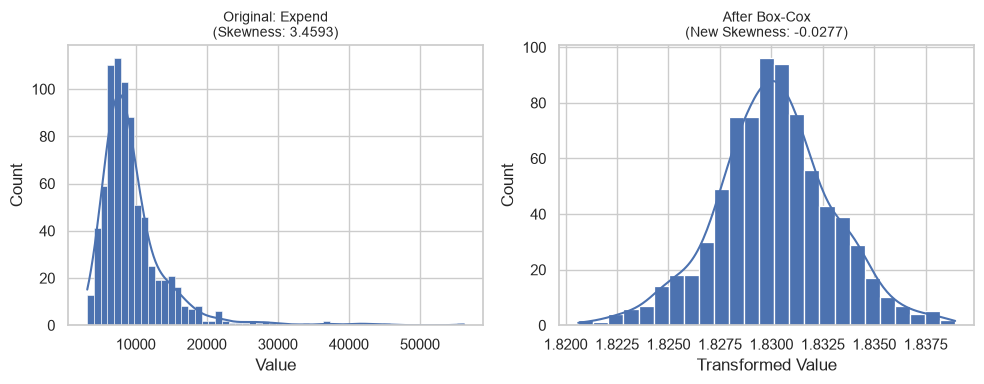

In [22]:
# Your code here
plot_transformations(college, skew)

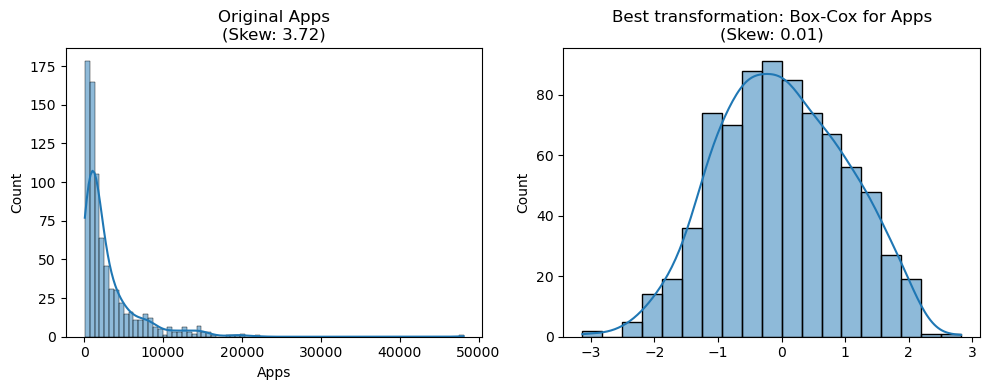

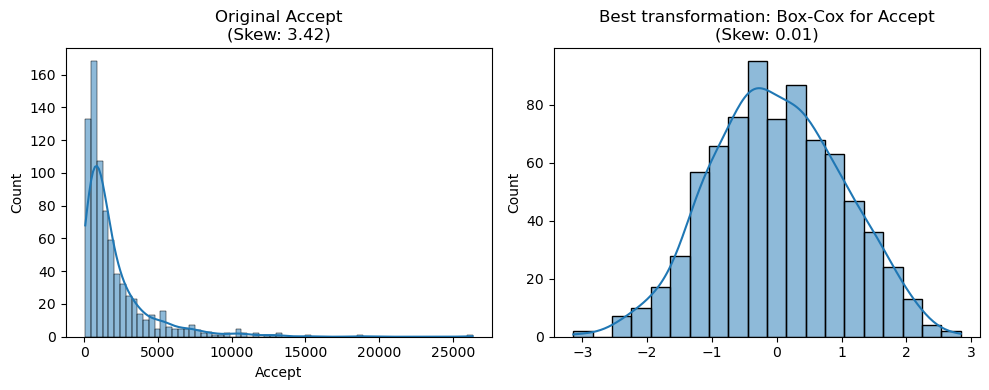

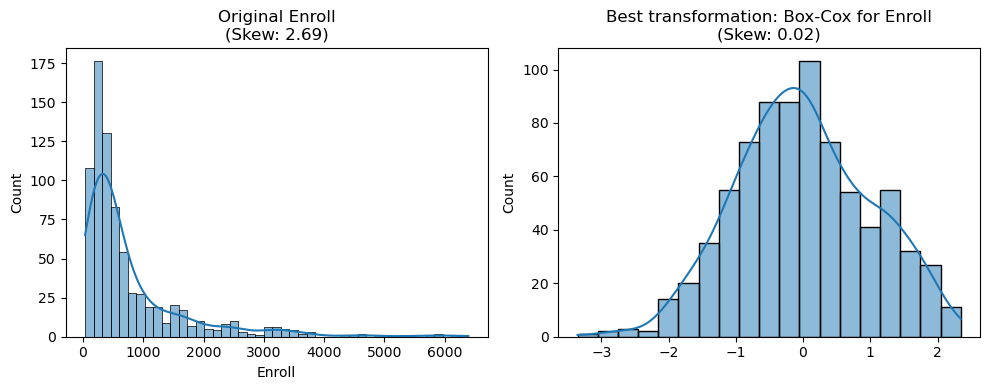

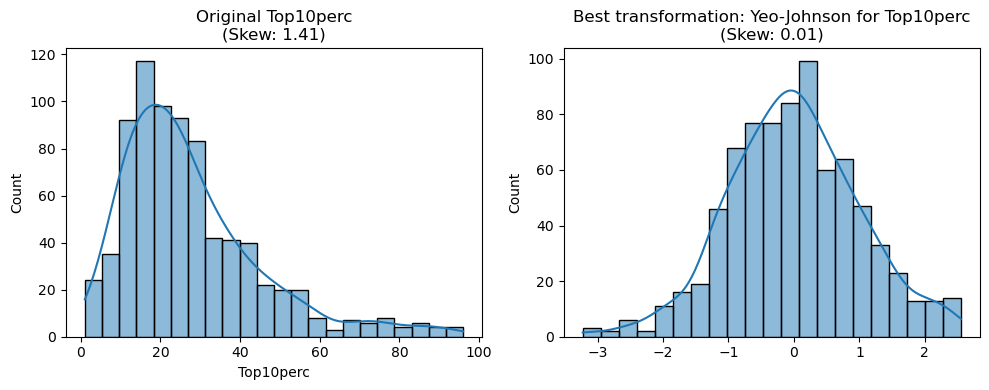

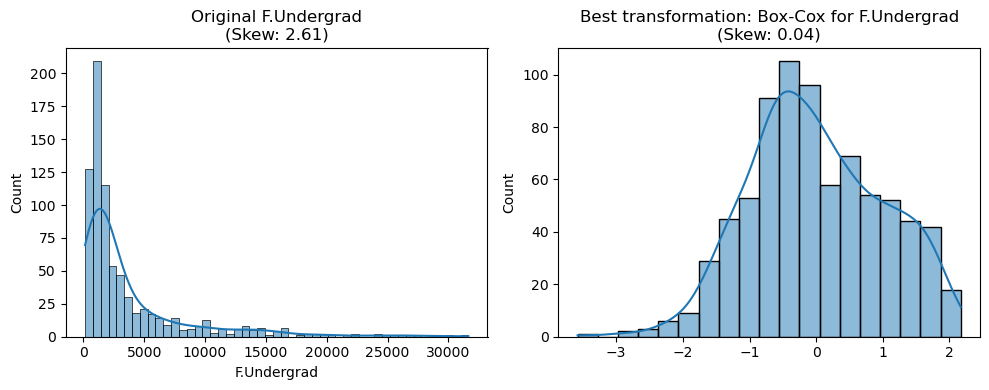

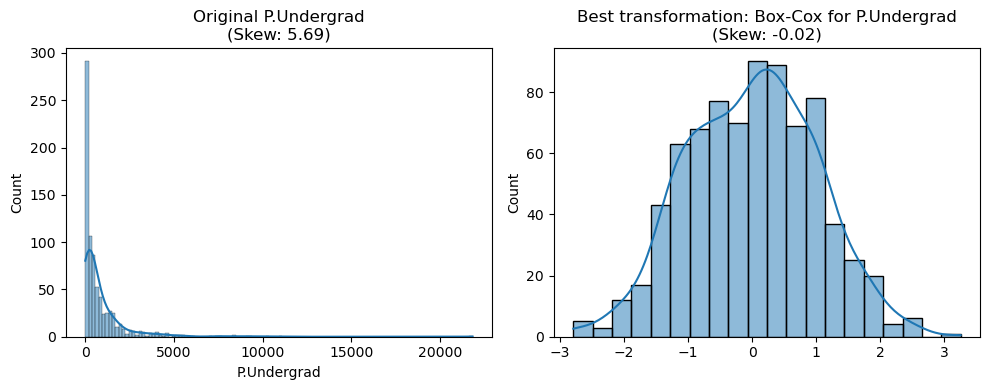

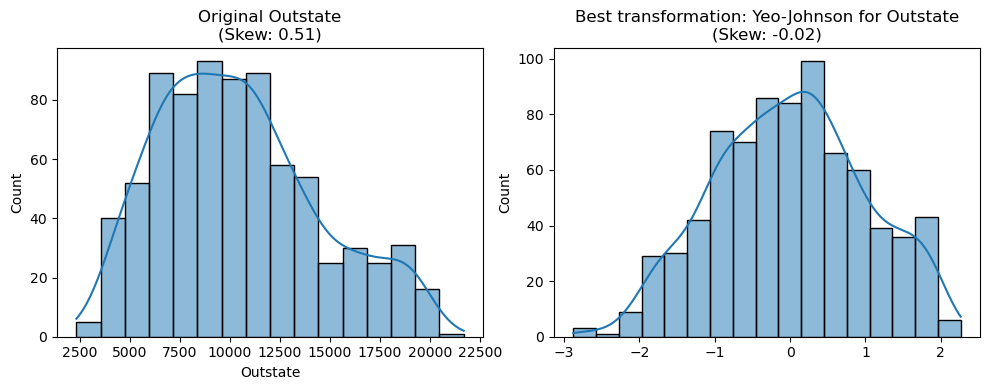

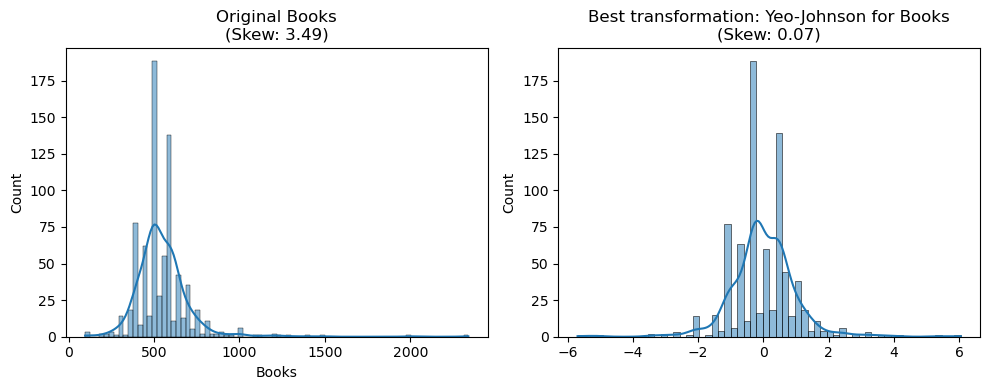

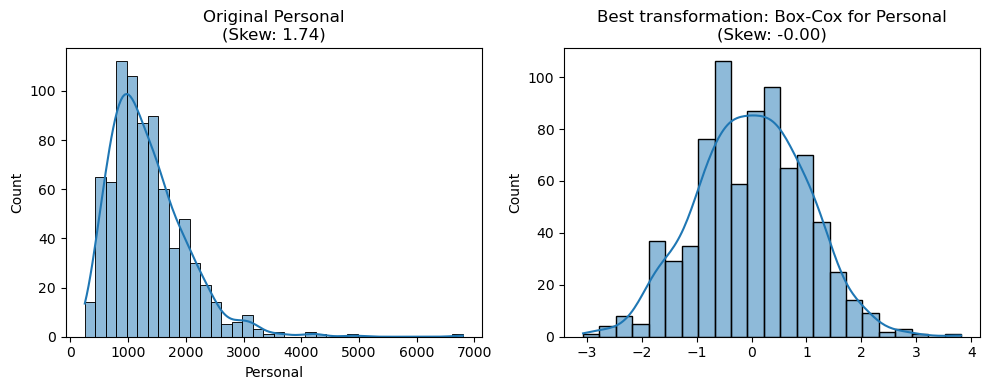

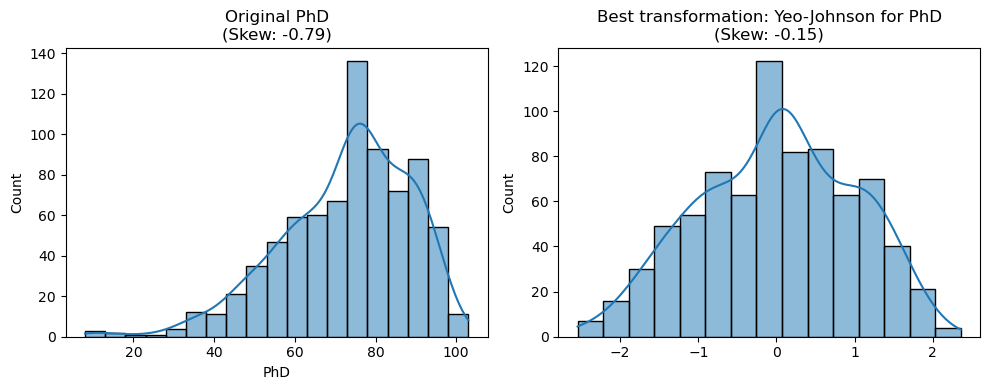

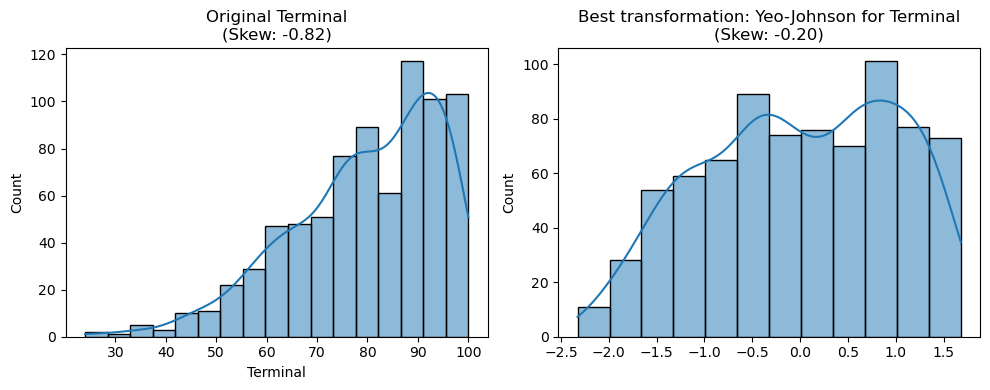

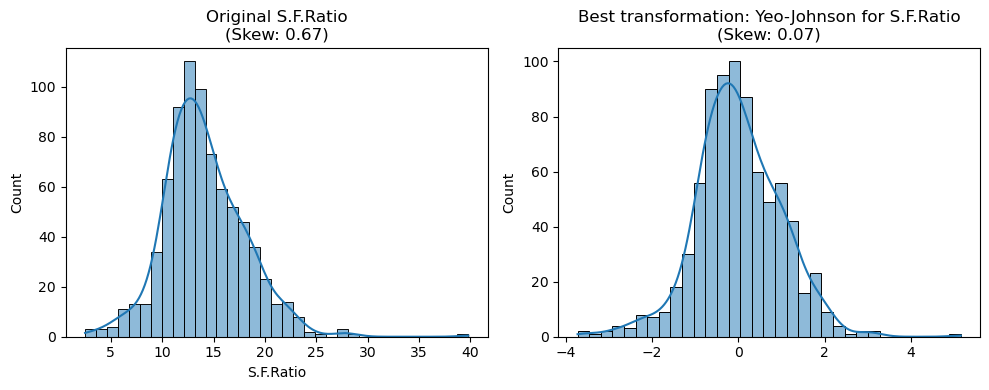

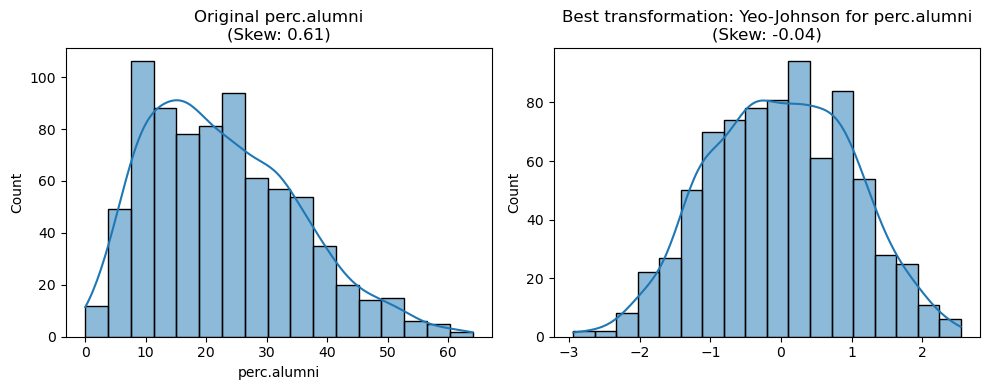

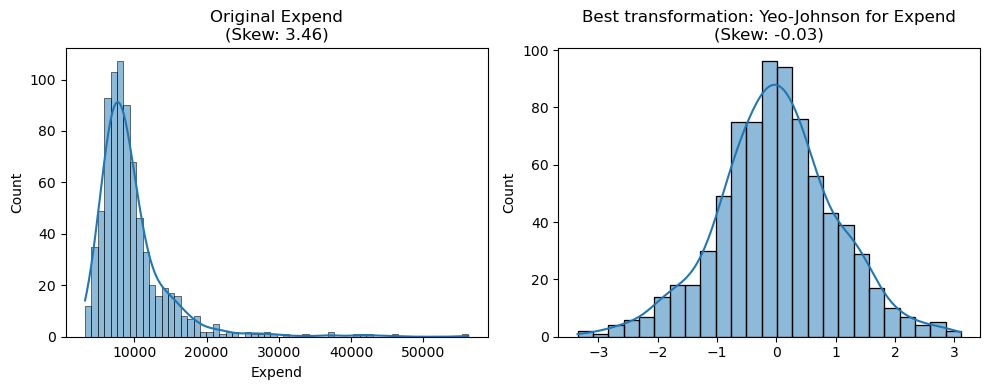

In [ ]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [23]:
trans_cols = []

# Your code here

cols_to_transform = skew[
    skew['Recommended Transformation'] != "No transformation needed"
]

for idx, row in cols_to_transform.iterrows():
    col = row['Feature']
    rec = row['Recommended Transformation']
    new_col = f"{col}_transformed"
    
    trans_cols.append(new_col)
    
    data = college[col]
    
    if "Box-Cox" in rec and (data > 0).all():
        college[new_col], _ = boxcox(data)
    elif "Log Plus One" in rec or "np.log1p" in rec:
        college[new_col] = np.log1p(data)
    elif "Log: np.log(x)" in rec and (data > 0).all():
        college[new_col] = np.log(data)
    else:
        college[new_col], _ = yeojohnson(data)

print(college.shape)
college[trans_cols].head()

(777, 33)


,Apps_transformed,Accept_transformed,Enroll_transformed,Top10perc_transformed,F.Undergrad_transformed,P.Undergrad_transformed,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,perc.alumni_transformed,Expend_transformed
0,5.730375,5.620215,4.143049,4.810281,3.769302,8.713915,59.118424,9.288880,10.374877,2504.239962,34148.774234,7.640162,4.953607,1.828730
1,5.889258,5.888543,4.014993,4.037028,3.756515,10.316290,70.749840,10.448462,9.706972,427.169553,2801.807925,5.860981,5.900711,1.831689
2,5.642123,5.548986,3.847907,4.711661,3.568664,5.815935,68.569551,9.032160,9.276476,1433.028797,22055.928365,6.087930,8.505877,1.830396
3,4.883064,4.814571,3.453920,7.235080,3.401005,5.119856,72.124122,9.288880,8.798545,4333.028101,60412.083923,4.254327,9.568133,1.835020
4,4.372223,4.215432,2.993412,4.037028,3.202743,9.631371,59.459747,10.600468,9.706972,2953.457225,27695.561321,5.762129,1.435605,1.831929


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [24]:
# Your code here 
college['Accept_Rate'] = college['Accept'] / college['Apps']

# Converting to percentage
college['Accept_Rate'] = (college['Accept'] / college['Apps']) * 100

college[['Apps', 'Accept', 'Accept_Rate']].head()

,Apps,Accept,Accept_Rate
0,1660,1232,74.216867
1,2186,1924,88.014639
2,1428,1097,76.820728
3,417,349,83.693046
4,193,146,75.647668


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [25]:
# Your code here 
labels = ['Low', 'Medium', 'High']

college['Outstate_Tier'] = pd.cut(college['Outstate'], bins=3, labels=labels)

college[['Outstate', 'Outstate_Tier']].head()

,Outstate,Outstate_Tier
0,7440,Low
1,12280,Medium
2,11250,Medium
3,12960,Medium
4,7560,Low


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [26]:
# Your code here 
tier_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

college['Outstate_Tier_encoded'] = college['Outstate_Tier'].map(tier_mapping).astype('Int64')

college[['Outstate', 'Outstate_Tier', 'Outstate_Tier_encoded']].head()

,Outstate,Outstate_Tier,Outstate_Tier_encoded
0,7440,Low,0
1,12280,Medium,1
2,11250,Medium,1
3,12960,Medium,1
4,7560,Low,0


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [27]:
# Your code here 
college['Private_encoded'] = (college['Private'] == 'Yes').astype(int)
college.head()

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,perc.alumni_transformed,Expend_transformed,Accept_Rate,Outstate_Tier,Outstate_Tier_encoded,Private_encoded
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,10.374877,2504.239962,34148.774234,7.640162,4.953607,1.828730,74.216867,Low,0,1
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,9.706972,427.169553,2801.807925,5.860981,5.900711,1.831689,88.014639,Medium,1,1
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,9.276476,1433.028797,22055.928365,6.087930,8.505877,1.830396,76.820728,Medium,1,1
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,8.798545,4333.028101,60412.083923,4.254327,9.568133,1.835020,83.693046,Medium,1,1
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,9.706972,2953.457225,27695.561321,5.762129,1.435605,1.831929,75.647668,Low,0,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [28]:
cols_to_scale = []

# Your code here 

cols_to_scale = trans_cols + ['Accept_Rate', 'Outstate_Tier_encoded', 'Private_encoded']

scaler = StandardScaler()

scaled_data = scaler.fit_transform(college[cols_to_scale])

scaled_col_names = [f"{col}_scaled" for col in cols_to_scale]
college[scaled_col_names] = scaled_data

college[scaled_col_names].head()

,Apps_transformed_scaled,Accept_transformed_scaled,Enroll_transformed_scaled,Top10perc_transformed_scaled,F.Undergrad_transformed_scaled,P.Undergrad_transformed_scaled,Outstate_transformed_scaled,Books_transformed_scaled,Personal_transformed_scaled,PhD_transformed_scaled,Terminal_transformed_scaled,S.F.Ratio_transformed_scaled,perc.alumni_transformed_scaled,Expend_transformed_scaled,Accept_Rate_scaled,Outstate_Tier_encoded_scaled,Private_encoded_scaled
0,0.027794,0.041028,0.493375,-0.053119,0.433599,0.300156,-0.693452,-0.614254,1.271398,-0.290438,-0.282374,1.019033,-0.834712,-0.491183,-0.032372,-1.098797,0.612553
1,0.282920,0.485821,0.142214,-0.584905,0.365382,0.868239,0.556270,1.302365,0.456551,-2.177364,-2.248129,-0.434462,-0.432329,0.552362,0.906193,0.358140,0.612553
2,-0.113916,-0.077046,-0.315977,-0.120942,-0.636774,-0.727254,0.322012,-1.038575,-0.068655,-1.263585,-1.040711,-0.249057,0.674492,0.096393,0.144750,0.358140,0.612553
3,-1.332769,-1.294446,-1.396388,1.614476,-1.531207,-0.974032,0.703928,-0.614254,-0.651734,1.370935,1.364588,-1.747012,1.125798,1.726997,0.612225,0.358140,0.612553
4,-2.153050,-2.287608,-2.659212,-0.584905,-2.588901,0.625418,-0.656779,1.553608,0.456551,0.117656,-0.687052,-0.515219,-2.329357,0.637044,0.064955,-1.098797,0.612553


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

In [29]:
college_updated = college.copy()

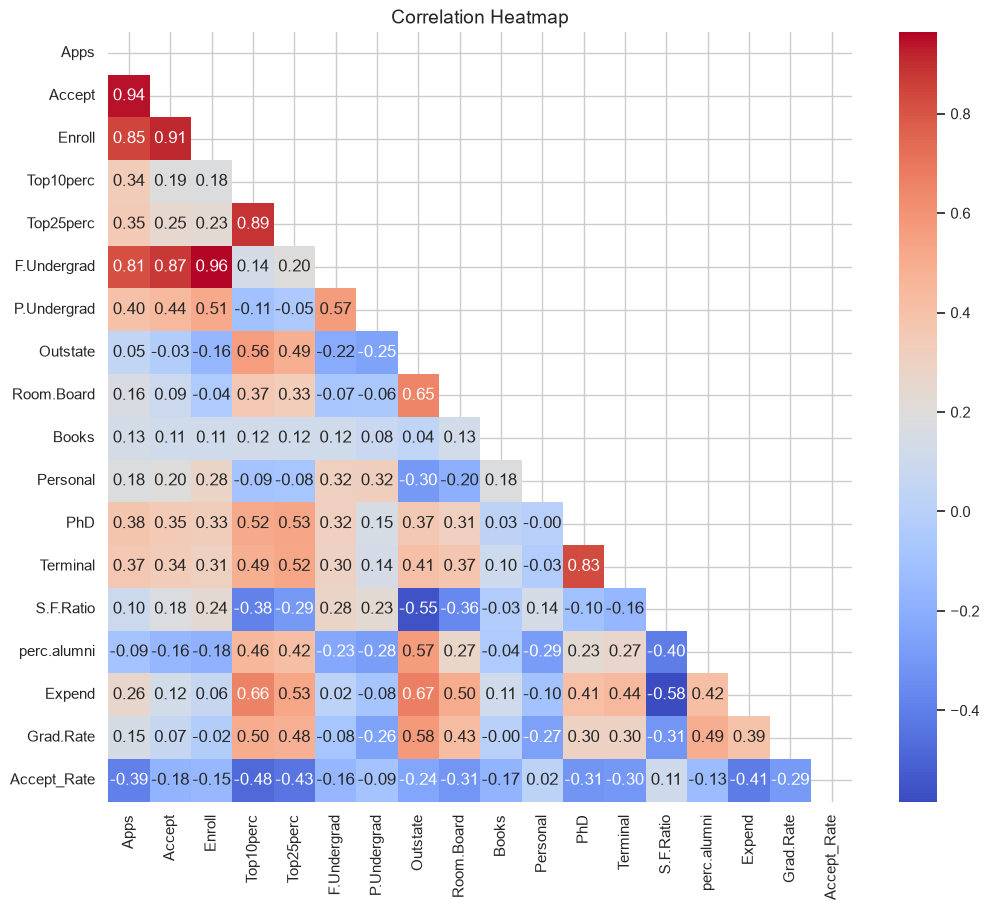

In [30]:
orig_cols = [
    col for col in college.select_dtypes(include=[np.number]).columns 
    if not col.endswith(('_transformed', '_encoded', '_scaled'))
]

corr = college[orig_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

In [31]:
target = 'Grad.Rate'
threshold = 0.8

corr = college_updated[orig_cols].corr().abs()

cols = [c for c in corr.columns if c != target]

to_drop = set()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]
        
        if corr.loc[col1, col2] >= threshold:
            corr1 = corr.loc[col1, target]
            corr2 = corr.loc[col2, target]
            
            if corr1 >= corr2:
                to_drop.add(col2)
            else:
                to_drop.add(col1)

print("Columns to drop:", list(to_drop))

college_updated = college_updated.drop(columns=list(to_drop))

Columns to drop: ['Accept', 'Enroll', 'Top25perc', 'F.Undergrad', 'Terminal']


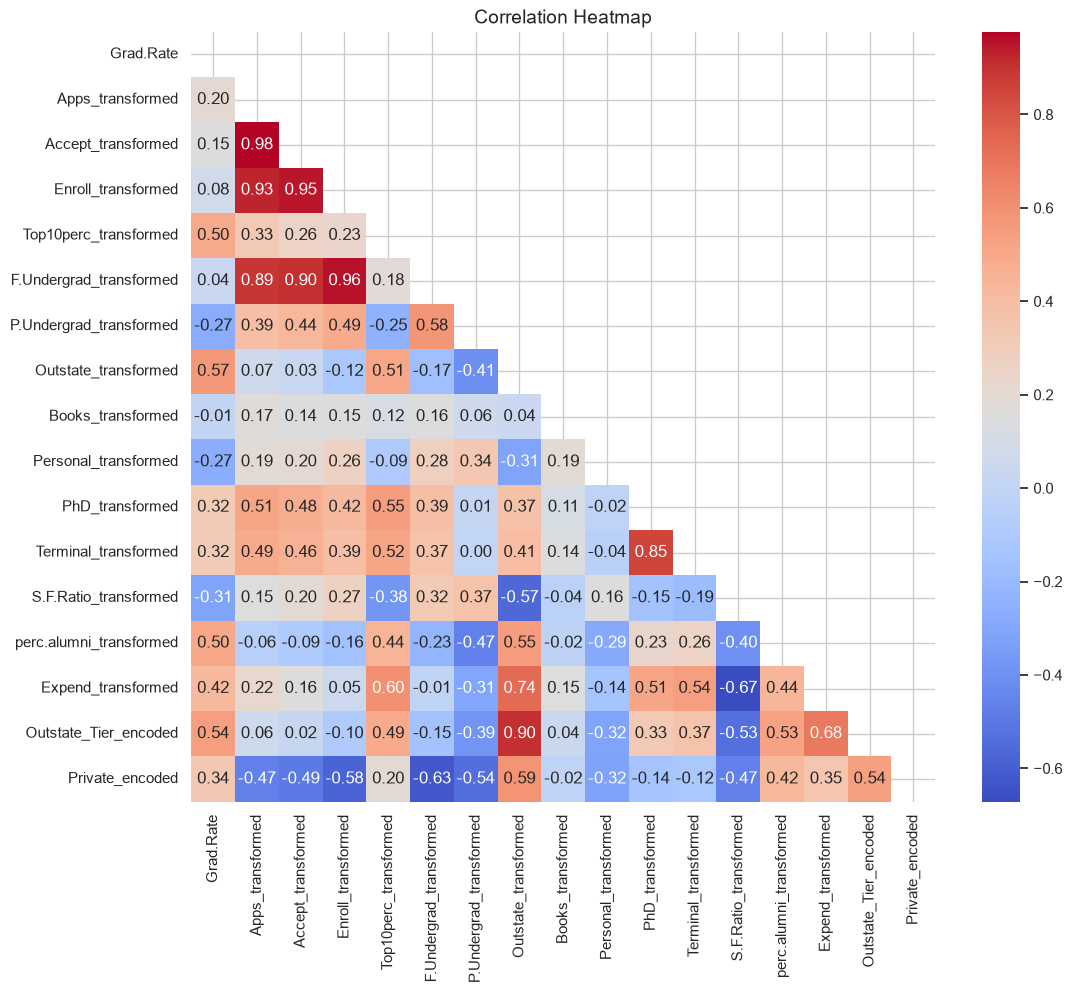

In [32]:
trans_encoded_cols = [
    col for col in college.select_dtypes(include=[np.number]).columns 
    if col.endswith(('_transformed', '_encoded', 'Grad.Rate'))
]

corr = college[trans_encoded_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

In [33]:
target = 'Grad.Rate'
threshold = 0.8

corr = college_updated[trans_encoded_cols].corr().abs()

cols = [c for c in corr.columns if c != target]

to_drop = set()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]
        
        if corr.loc[col1, col2] >= threshold:
            corr1 = corr.loc[col1, target]
            corr2 = corr.loc[col2, target]
            
            if corr1 >= corr2:
                to_drop.add(col2)
            else:
                to_drop.add(col1)

print("Columns to drop:", list(to_drop))

college_updated = college_updated.drop(columns=list(to_drop))

Columns to drop: ['Enroll_transformed', 'F.Undergrad_transformed', 'PhD_transformed', 'Accept_transformed', 'Outstate_Tier_encoded']


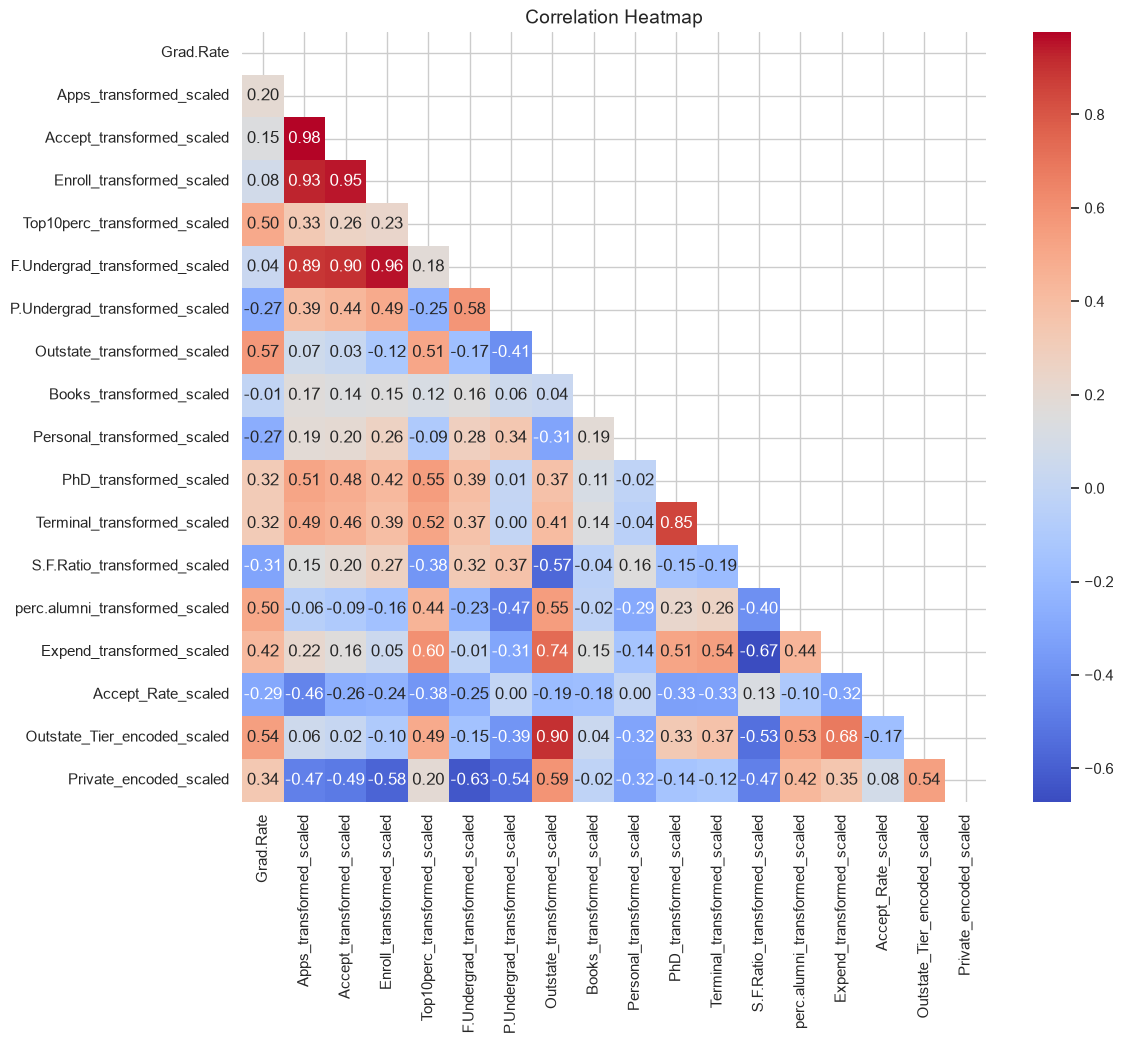

In [34]:
scaled_cols = [
    col for col in college.select_dtypes(include=[np.number]).columns 
    if col.endswith(('_scaled', 'Grad.Rate'))
]

corr = college[scaled_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

In [35]:
target = 'Grad.Rate'
threshold = 0.8

corr = college_updated[scaled_cols].corr().abs()

cols = [c for c in corr.columns if c != target]

to_drop = set()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]
        
        if corr.loc[col1, col2] >= threshold:
            corr1 = corr.loc[col1, target]
            corr2 = corr.loc[col2, target]
            
            if corr1 >= corr2:
                to_drop.add(col2)
            else:
                to_drop.add(col1)

print("Columns to drop:", list(to_drop))

college_updated = college_updated.drop(columns=list(to_drop))

Columns to drop: ['F.Undergrad_transformed_scaled', 'Accept_transformed_scaled', 'PhD_transformed_scaled', 'Outstate_Tier_encoded_scaled', 'Enroll_transformed_scaled']


## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [36]:
# Your code here 

target = 'Grad.Rate'

raw_features = [
    col for col in college_updated.select_dtypes(include=[np.number]).columns
    if col != target and not col.endswith(('_transformed', '_encoded', '_scaled'))
]

transformed_features = [
    col for col in college_updated.select_dtypes(include=[np.number]).columns
    if col != target and col.endswith(('_transformed', '_encoded', '_scaled'))
]

X_raw = college_updated[raw_features]
X_transformed = college_updated[transformed_features]
y = college_updated[target]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y, test_size=0.2, random_state=1)

X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(X_transformed, y, test_size=0.2, random_state=1)

print(f"Raw train shape: {X_train_raw.shape}, test shape: {X_test_raw.shape}")
print(f"Transformed train shape: {X_train_tr.shape}, test shape: {X_test_tr.shape}")

Raw train shape: (621, 12), test shape: (156, 12)
Transformed train shape: (621, 23), test shape: (156, 23)


#### 15. Fit a linear regression using the raw predictors


In [37]:
untrans_predictors = []

# Your code here

untrans_predictors = raw_features

model_raw = LinearRegression()
model_raw.fit(X_train_raw, y_train_raw)

y_pred_raw = model_raw.predict(X_test_raw)
r2_raw = r2_score(y_test_raw, y_pred_raw)

print("Pre-Scaled Untransformed R-squared: ", r2_raw)

# Seeing if scaling makes a difference
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train_raw)

y_pred_scaled = model_scaled.predict(X_test_scaled)
r2_scaled = r2_score(y_test_raw, y_pred_scaled)

print("Scaled Untransformed R-squared: ", r2_scaled)

Pre-Scaled Untransformed R-squared:  0.4817484270430026
Scaled Untransformed R-squared:  0.481748427043002


#### 16. Fit the same model using the log-transformed predictors

In [38]:
trans_predictors = []

# Your code here 

trans_predictors = transformed_features

model_transformed = LinearRegression()
model_transformed.fit(X_train_tr, y_train_tr)

y_pred_tr = model_transformed.predict(X_test_tr)
r2_transformed = r2_score(y_test_tr, y_pred_tr)

print("Pre-Scaled Model R-squared: ", r2_transformed)

# Seeing if scaling makes a difference
scaled_features = [col for col in college_updated.columns if col.endswith('_scaled')]

if scaled_features:
    X_scaled_all = college_updated[scaled_features]
    
    X_train_sc, X_test_sc, y_train_sc, y_test_sc = train_test_split(X_scaled_all, y, test_size=0.2, random_state=1)
    
    model_scaled_tr = LinearRegression()
    model_scaled_tr.fit(X_train_sc, y_train_sc)
    
    y_pred_sc = model_scaled_tr.predict(X_test_sc)
    r2_scaled_transformed = r2_score(y_test_tr, y_pred_sc)
    
    print("Scaled Transformed Model R-squared: ", r2_scaled_transformed)
else:
    print("No columns ending with '_scaled' were found in college_updated.")

Pre-Scaled Model R-squared:  0.4842279408535879
Scaled Transformed Model R-squared:  0.48422794085355303


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [39]:
# Your code here 
print("Raw Model R-squared: ", r2_scaled)
print("Transformed Model R-squared: ", r2_scaled_transformed)

print("The difference between raw score and transformed score: ", r2_scaled_transformed-r2_scaled)

Raw Model R-squared:  0.481748427043002
Transformed Model R-squared:  0.48422794085355303
The difference between raw score and transformed score:  0.002479513810551004


In [ ]:
# there is a slight improvement after transforming the data

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [40]:
# Your code here 
college_updated.to_csv('college_transformed.csv', index=False)